Shape: (32, 5)

Columns:
Index(['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories'], dtype='str')

Data Types:
Duration      int64
Date            str
Pulse         int64
Maxpulse      int64
Calories    float64
dtype: object

Missing Values:
Duration    0
Date        1
Pulse       0
Maxpulse    0
Calories    2
dtype: int64

Duplicate Rows:
1
Duplicates before: 1
Duplicates after: 0


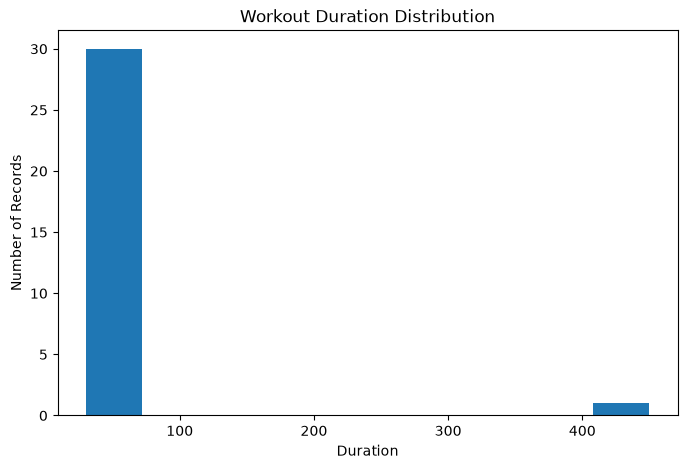

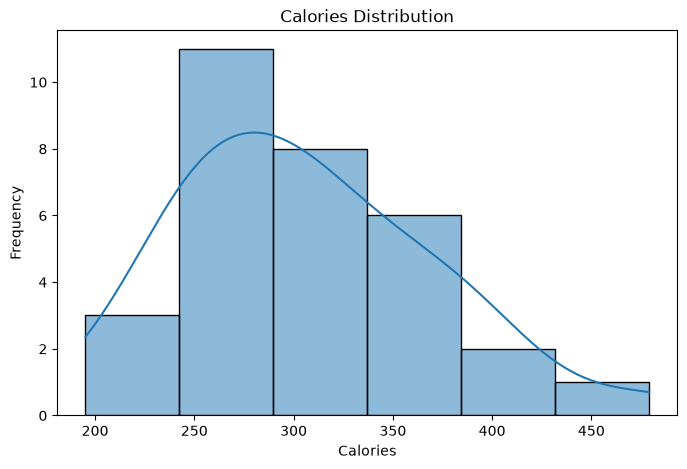

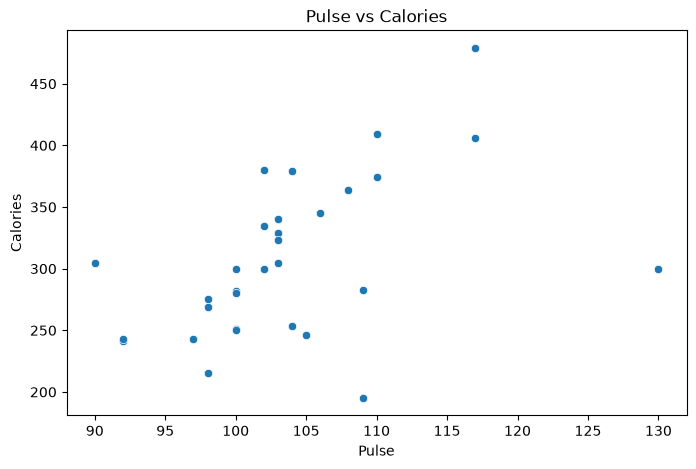

Final Shape: (31, 7)

Missing Values:
Duration               0
Date                   0
Pulse                  0
Maxpulse               0
Calories               0
Calories_per_Minute    0
Intensity              0
dtype: int64

Duplicate Rows:
0


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data.csv")

df.head()

print("Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df["Date"] = df["Date"].astype(str).str.replace("'", "", regex=False)

df["Date"] = pd.to_datetime(
    df["Date"],
    format="mixed",
    errors="coerce"
)

df["Date"].head()

df["Calories"].isnull().sum()

df["Calories"] = df["Calories"].fillna(df["Calories"].mean())
df["Calories"].isnull().sum()
df.loc[df["Date"].isnull(), "Date"] = pd.Timestamp("2020-12-22")
df["Date"].isnull().sum()
print("Duplicates before:", df.duplicated().sum())
df = df.drop_duplicates()
print("Duplicates after:", df.duplicated().sum())

df[df["Duration"] > 100]

long_workouts = df[df["Duration"] >= 60]

long_workouts.head()

high_pulse = df[df["Pulse"] > 110]

high_pulse.head()

df["Calories_per_Minute"] = df["Calories"] / df["Duration"]

df[["Duration", "Calories", "Calories_per_Minute"]].head()

df["Intensity"] = df["Pulse"].apply(
    lambda x: "High" if x >= 110 else "Normal"
)

df[["Pulse", "Intensity"]].head()

plt.figure(figsize=(8,5))

plt.hist(df["Duration"], bins=10)

plt.title("Workout Duration Distribution")
plt.xlabel("Duration")
plt.ylabel("Number of Records")

plt.show()

plt.figure(figsize=(8,5))

sns.histplot(df["Calories"], kde=True)

plt.title("Calories Distribution")
plt.xlabel("Calories")
plt.ylabel("Frequency")

plt.show()

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Pulse",
    y="Calories"
)

plt.title("Pulse vs Calories")
plt.xlabel("Pulse")
plt.ylabel("Calories")

plt.show()

print("Final Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

df.head()

df.to_csv("cleaned_data.csv", index=False)